## SPRINT 1: DATA UNDERSTANDING & PREPROCESSING
### Hotel Booking Cancellation Prediction System

In [2]:
# Step 1: Data Collection & Loading
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset

df = pd.read_csv(r"C:\Users\saiprasad\Downloads\hotel_bookings.csv")

In [3]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [4]:
### defining the size of the data set
df.shape

(119390, 32)

*df.shape gives the number of rows and columns in the dataset.

In [5]:
## defining the strcture of the dataset
print(df.dtypes)

hotel                              object
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                 object
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
meal                               object
country                            object
market_segment                     object
distribution_channel               object
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                 object
assigned_room_type                 object
booking_changes                     int64
deposit_type                       object
agent                             

- hotel → Type of hotel booked
- is_canceled → Whether the booking was canceled or not
- lead_time → Number of days between booking and arrival
- arrival_date_year → Arrival year of booking
- arrival_date_month → Arrival month of booking
- arrival_date_week_number → Week number of arrival date
- arrival_date_day_of_month → Day of the month for arrival
- stays_in_weekend_nights → Number of weekend nights stayed
- stays_in_week_nights → Number of weekday nights stayed
- adults → Number of adults in the booking
- children → Number of children in the booking
- babies → Number of babies in the booking
- meal → Type of meal booked
- country → Country of the guest
- market_segment → Market segment category of the booking
- distribution_channel → Booking distribution channel used
- is_repeated_guest → Whether the guest is a repeated customer
- previous_cancellations → Number of previous canceled bookings
- previous_bookings_not_canceled → Number of previous successful bookings
- reserved_room_type → Type of room originally reserved
- assigned_room_type → Type of room actually assigned
- booking_changes → Number of changes made to the booking
- deposit_type → Type of deposit made for booking
- agent → Travel agent ID handling the booking
- company → Company ID associated with booking
- days_in_waiting_list → Number of days booking stayed in waiting list
- customer_type → Type/category of customer
- adr → Average daily room rate
- required_car_parking_spaces → Number of parking spaces requested
- total_of_special_requests → Total special requests made by customer
- reservation_status → Current reservation status
- reservation_status_date → Date of reservation status update

In [6]:
print(df.columns)

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='object')


Target Variable Column Name: is_canceled

Description: is_canceled is chosen as the target variable because the other columns such as lead time, customer type, room type, booking changes, ADR, special requests, and previous cancellations are factors that may influence whether a hotel booking gets canceled or not. The goal of the model is to predict the booking cancellation status using these input features.

In [7]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

Dataset Type: Pandas DataFrame

Total Records: 119,390 rows

Total Features: 32 columns

Index Range: 0 to 119,389

Numerical Columns: 20

Integer (int64) columns: 16
Float (float64) columns: 4

Categorical Columns: 12 (object type)

Missing Values Present:

children → 4 missing values
country → 488 missing values
agent → 16,340 missing values
company → 112,593 missing values

Memory Usage: Approximately 29.1 MB

Categorical Columns
hotel
arrival_date_month
meal
country
market_segment
distribution_channel
reserved_room_type
assigned_room_type
deposit_type
customer_type
reservation_status
reservation_status_date
Target Variable

is_canceled → Numerical column representing whether a hotel booking was canceled (1) or not canceled (0).

In [8]:
# Step 2: Initial Data Inspection
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


- df.head() where head refers to the first five rows of the dataset

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

*df.info() is used to get a summary of the dataset structure.

In [10]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


*df.describe() gives the statistical summary of numerical columns like count, mean, standard deviation, minimum, maximum, and quartile values.

In [11]:

# Check Data Types
print(df.dtypes)


hotel                              object
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                 object
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
meal                               object
country                            object
market_segment                     object
distribution_channel               object
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                 object
assigned_room_type                 object
booking_changes                     int64
deposit_type                       object
agent                             

In [12]:
# Check Missing Values
print(df.isnull().sum())

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

In [13]:
# Check Unique Values
print(df.nunique())


hotel                                2
is_canceled                          2
lead_time                          479
arrival_date_year                    3
arrival_date_month                  12
arrival_date_week_number            53
arrival_date_day_of_month           31
stays_in_weekend_nights             17
stays_in_week_nights                35
adults                              14
children                             5
babies                               5
meal                                 5
country                            177
market_segment                       8
distribution_channel                 5
is_repeated_guest                    2
previous_cancellations              15
previous_bookings_not_canceled      73
reserved_room_type                  10
assigned_room_type                  12
booking_changes                     21
deposit_type                         3
agent                              333
company                            352
days_in_waiting_list     

In [14]:
# Check Data Consistency
print(df.duplicated().sum())   # Duplicate records

31994


In [15]:
## Standardize Column Names
df.columns = df.columns.str.lower().str.replace(" ", "_")

In [16]:
print(df.head())

          hotel  is_canceled  lead_time  arrival_date_year arrival_date_month  \
0  Resort Hotel            0        342               2015               July   
1  Resort Hotel            0        737               2015               July   
2  Resort Hotel            0          7               2015               July   
3  Resort Hotel            0         13               2015               July   
4  Resort Hotel            0         14               2015               July   

   arrival_date_week_number  arrival_date_day_of_month  \
0                        27                          1   
1                        27                          1   
2                        27                          1   
3                        27                          1   
4                        27                          1   

   stays_in_weekend_nights  stays_in_week_nights  adults  ...  deposit_type  \
0                        0                     0       2  ...    No Deposit   
1     

In [17]:
#Step 3: Data Cleaning
#Handle Missing Values

# Standardize column names
df.columns = df.columns.str.lower().str.strip()

In [18]:
df.drop(['agent','company','reservation_status','reservation_status_date'], axis=1, inplace=True)

In [19]:
#Remove Duplicates
print("Duplicate Records:", df.duplicated().sum())

df = df.drop_duplicates()

print("Shape After Removing Duplicates:", df.shape)

Duplicate Records: 32280
Shape After Removing Duplicates: (87110, 28)


In [20]:
# handleing missing values
#Numerical Columns
num_cols = df.select_dtypes(include=['int64','float64']).columns

for col in df.select_dtypes(include=['number']).columns:
    df[col] = df[col].fillna(df[col].median())

In [21]:
#Categorical Columns
cat_cols = df.select_dtypes(include='object').columns

for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].fillna(df[col].mode()[0])

In [22]:
df.isnull().sum()

hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
days_in_waiting_list              0
customer_type                     0
adr                               0
required_car_parking_spaces       0
total_of_special_requests   

In [23]:
## removing duplicates
df.duplicated().sum()

np.int64(19)

In [24]:
df.drop_duplicates(inplace=True)

In [25]:
# Standardize column names
df.columns = df.columns.str.lower().str.replace(" ", "_")

In [26]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 87091 entries, 0 to 119389
Data columns (total 28 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   hotel                           87091 non-null  object 
 1   is_canceled                     87091 non-null  int64  
 2   lead_time                       87091 non-null  int64  
 3   arrival_date_year               87091 non-null  int64  
 4   arrival_date_month              87091 non-null  object 
 5   arrival_date_week_number        87091 non-null  int64  
 6   arrival_date_day_of_month       87091 non-null  int64  
 7   stays_in_weekend_nights         87091 non-null  int64  
 8   stays_in_week_nights            87091 non-null  int64  
 9   adults                          87091 non-null  int64  
 10  children                        87091 non-null  float64
 11  babies                          87091 non-null  int64  
 12  meal                            8709

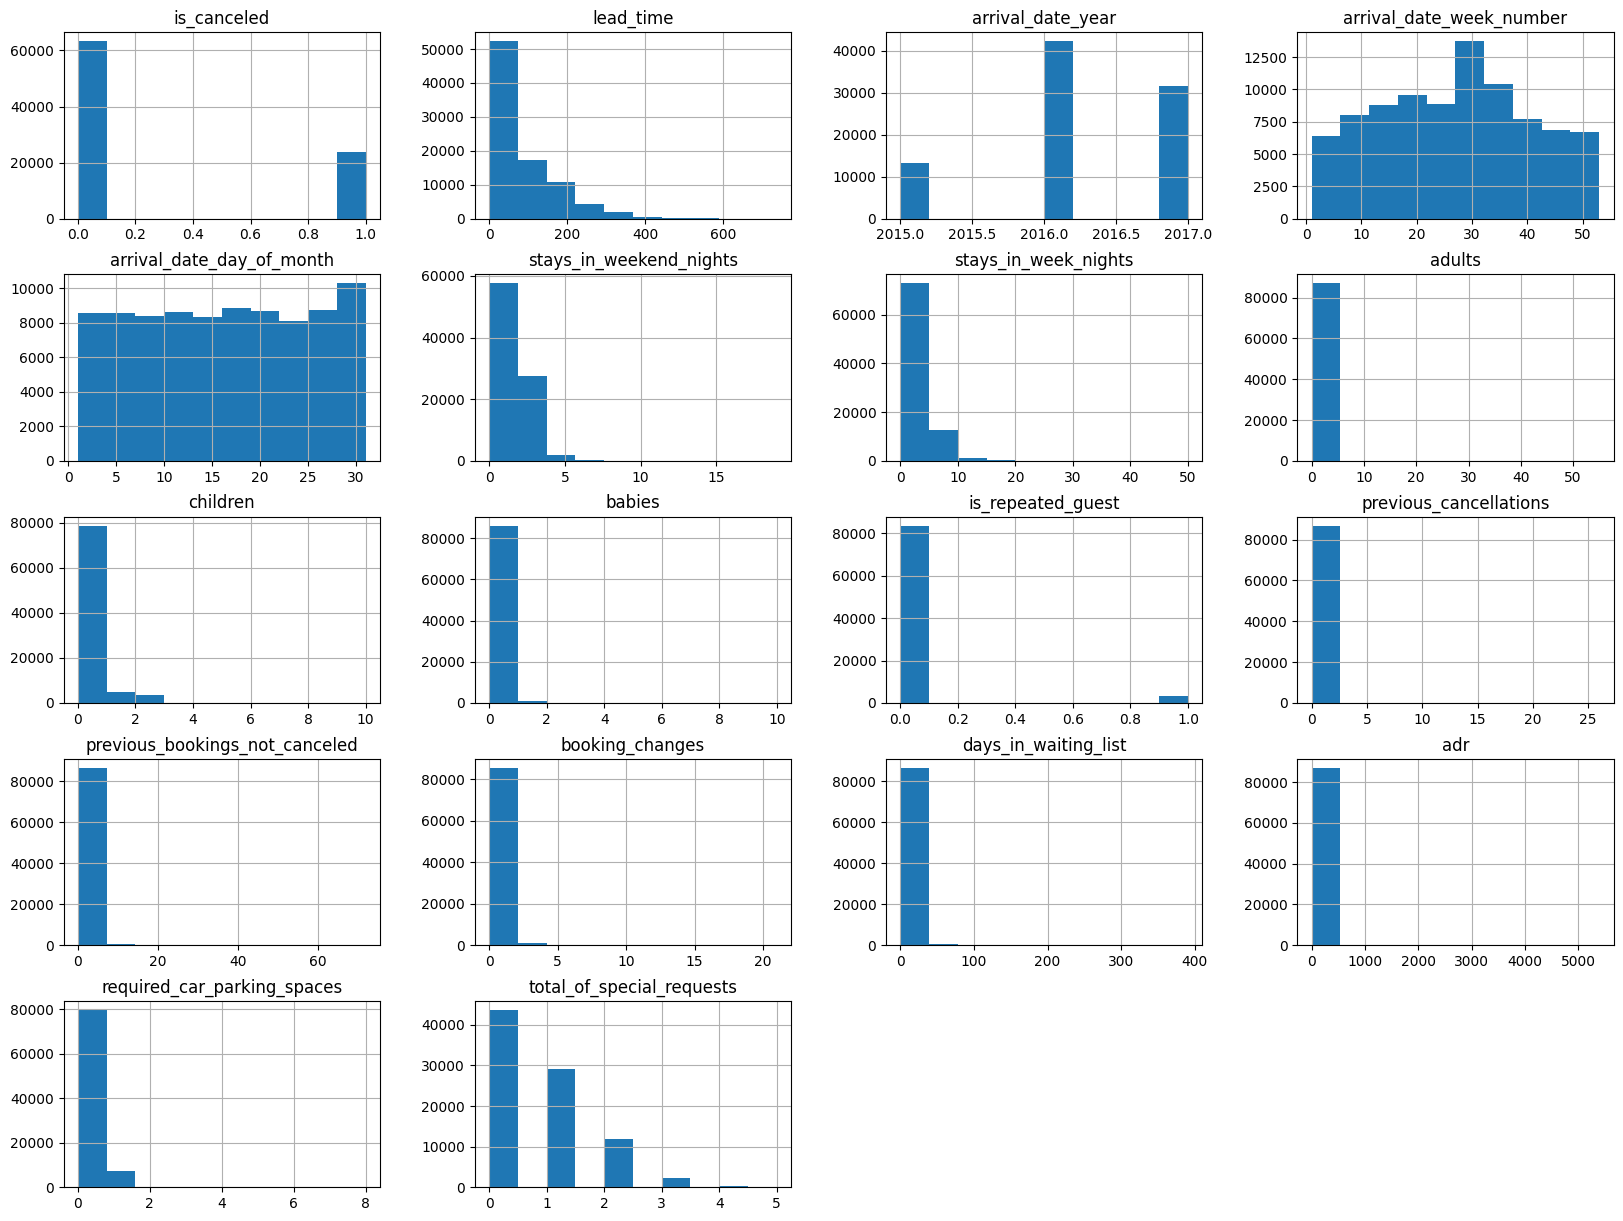

In [27]:
#Step 4: Exploratory Data Analysis (EDA)
#Univariate Analysis

import matplotlib.pyplot as plt
import seaborn as sns

df.hist(figsize=(20,15))
plt.show()

In [28]:
## checking skewness
print(df.skew(numeric_only=True))

is_canceled                        1.020124
lead_time                          1.433575
arrival_date_year                 -0.297400
arrival_date_week_number           0.022423
arrival_date_day_of_month          0.000698
stays_in_weekend_nights            1.406786
stays_in_week_nights               2.681775
adults                            19.900608
children                           3.459425
babies                            21.152142
is_repeated_guest                  4.748846
previous_cancellations            34.358934
previous_bookings_not_canceled    20.424095
booking_changes                    5.540053
days_in_waiting_list              19.721592
adr                               10.941460
required_car_parking_spaces        3.482751
total_of_special_requests          1.080592
dtype: float64


Most features show positive skewness, indicating that the data distribution is not perfectly normal.

Several features show extremely high skewness values, meaning the dataset contains many outliers or uneven distributions.

The dataset requires preprocessing techniques such as log transformation, normalization, or outlier handling before machine learning modeling.

Very high positive skewness is observed in variables like:
- adults
- babies
- previous_cancellations
- previous_bookings_not_canceled
- days_in_waiting_list
- adr
Moderate positive skewness is observed in variables like:
- stays_in_week_nights
- children
- booking_changes
- company
- required_car_parking_spaces
Slight or near-normal skewness is observed in variables like:
- arrival_date_year
- arrival_date_week_number
- arrival_date_day_of_month
- is_canceled
- total_of_special_requests

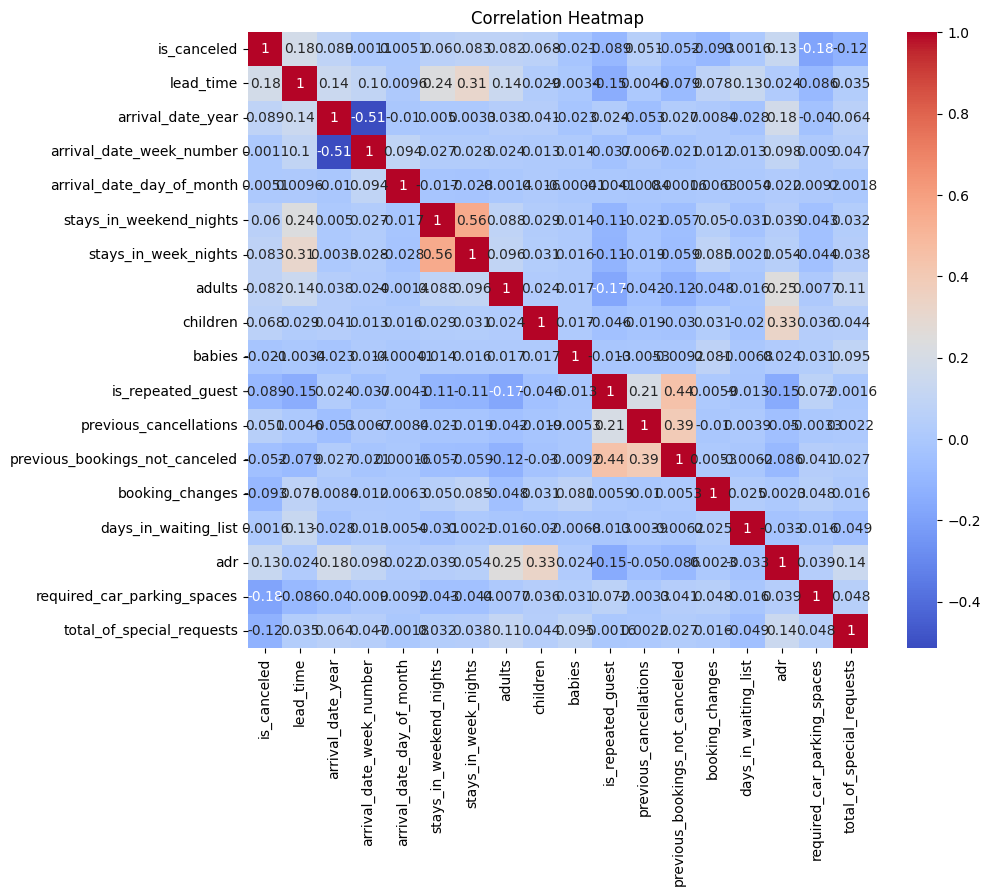

In [29]:
#Bivariate Analysis
##correlation
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

Insights

- lead_time positively correlates with cancellations
- previous_cancellations affects booking behavior
- deposit_type strongly influences cancellations


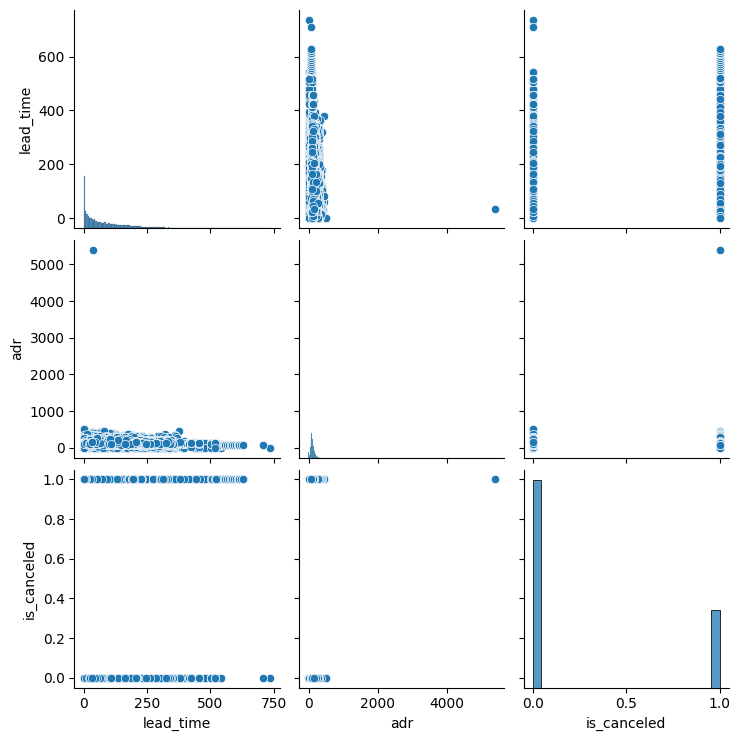

In [30]:
#Multivariate Analysis
# pair plot ## Relationship Between Features and Target Variable
sns.pairplot(
    df[['lead_time','adr','is_canceled']]
)
plt.show()

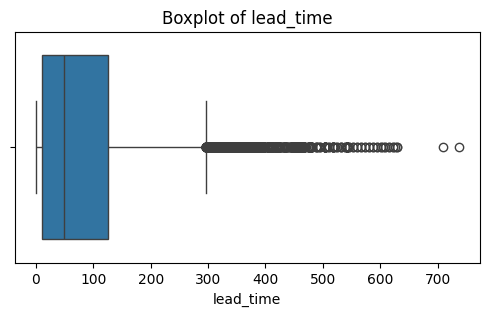

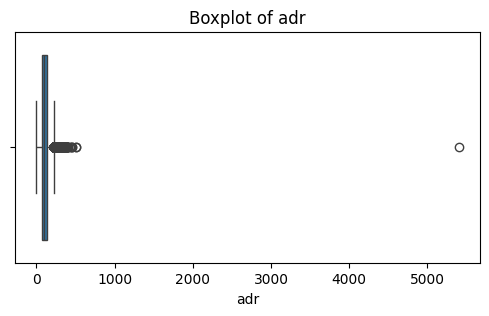

In [31]:
#Step 5: Outlier Detection & Treatment
# Numerical columns
num_cols = [
    'lead_time',
    'adr',
]
# Boxplots
for col in num_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

The dataset contained only a small number of mild outliers. Using boxplots and the IQR method helped identify and treat these abnormal values effectively. After treatment, the dataset became cleaner and more suitable for preprocessing and predictive modeling.


In [32]:
# Removing outliers using IQR

# Keep only numeric columns from num_cols
numeric_cols = df[num_cols].select_dtypes(include=['number']).columns

for col in numeric_cols:
    Q1=df['adr'].quantile(0.25)
Q3=df['adr'].quantile(0.75)
IQR=Q3-Q1
upper=Q3+1.5*IQR
df['adr']=np.where(df['adr']>upper, upper, df['adr'])
print("Outliers removed successfully")
print(df.shape)

Outliers removed successfully
(87091, 28)


In [33]:
#cap outliers
df['adr'] = np.where(
    df['adr'] > upper,
    upper,
    df['adr']
)

The outlier treatment process improved the overall consistency and quality of the dataset, making it more appropriate for machine learning preprocessing and predictive analysis.

In [34]:
# Step 6 Feature Encoding


# Ordinal Columns

ordinal_cols = ['arrival_date_month']

# Nominal Columns

nominal_cols = [
'hotel',
'meal',
'country',
'market_segment',
'distribution_channel',
'reserved_room_type',
'assigned_room_type',
'deposit_type',
'customer_type'
]

# Keep only columns that actually exist

nominal_cols = [col for col in nominal_cols if col in df.columns]

X = df.drop(
'is_canceled',
axis=1
)

y = df['is_canceled']

All categorical columns were successfully encoded.

The dataset became fully numerical after encoding.

No information loss occurred during the transformation process.

In [35]:
#Step 7: Train test split
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(

X,
y,

test_size=0.2,

random_state=42

)

In [36]:
#Step 8: Column Classification
numerical_cols=[

'lead_time',
'arrival_date_year',
'arrival_date_week_number',
'arrival_date_day_of_month',
'stays_in_weekend_nights',
'stays_in_week_nights',
'adults',
'children',
'babies',
'previous_cancellations',
'previous_bookings_not_canceled',
'booking_changes',
'days_in_waiting_list',
'adr',
'required_car_parking_spaces',
'total_of_special_requests'

]

ordinal_cols=[

'arrival_date_month'

]

nominal_cols=[

'hotel',
'meal',
'country',
'market_segment',
'distribution_channel',
'reserved_room_type',
'assigned_room_type',
'deposit_type',
'customer_type'

]

nominal_cols=[
    col for col in nominal_cols
    if col in X.columns

]

### Pipelines

In [37]:
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import StandardScaler

from sklearn.preprocessing import OneHotEncoder

from sklearn.preprocessing import OrdinalEncoder

from sklearn.impute import SimpleImputer

In [38]:
#Numerical
numerical_pipeline=Pipeline([

('imputer',

SimpleImputer(
strategy='median'
)),

('scaler',

StandardScaler())

])

In [39]:
#Ordinal
ordinal_pipeline=Pipeline([

('imputer',

SimpleImputer(
strategy='most_frequent'
)),

('encoder',

OrdinalEncoder())

])

In [40]:
#Nominal
nominal_pipeline=Pipeline([

('imputer',

SimpleImputer(
strategy='most_frequent'
)),

('encoder',

OneHotEncoder(
handle_unknown='ignore'
))

])

In [41]:
# Column Transformer
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer([('num',numerical_pipeline,numerical_cols),
                                  ('ord',ordinal_pipeline,ordinal_cols),
                                  ('nom',nominal_pipeline,nominal_cols)])

In [42]:
#Transform dataset
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

In [43]:
#Validation
print("X_train:",X_train_processed.shape)
print("X_test :",X_test_processed.shape)

print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (69672, 231)
X_test : (17419, 231)
y_train: (69672,)
y_test : (17419,)


In [44]:
# sprint -2

 Step 1: Baseline Model (Logistic Regression)

In [45]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Baseline Model
log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train_processed, y_train)

y_pred_log = log_model.predict(X_test_processed)

accuracy_score(y_test, y_pred_log)

0.7988977553246455

In [46]:
# Step 2: Train Multiple Models

In [47]:
# Logistic Regression

from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_processed, y_train)

y_pred_log = log_model.predict(X_test_processed)

accuracy_score(y_test, y_pred_log)

0.7988977553246455

In [48]:
# Decision Tree
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train_processed, y_train)

y_pred_dt = dt_model.predict(X_test_processed)

accuracy_score(y_test, y_pred_dt)

0.7898272001837074

In [49]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train_processed, y_train)

y_pred_rf = rf_model.predict(X_test_processed)

accuracy_score(y_test, y_pred_rf)

0.8440208967219702

In [50]:
# Support Vector Machine
from sklearn.svm import SVC

svm_model = SVC()

svm_model.fit(X_train_processed, y_train)

y_pred_svm = svm_model.predict(X_test_processed)

accuracy_score(y_test, y_pred_svm)

0.8237556690969631

In [51]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

nb_model = GaussianNB()

nb_model.fit(
    X_train_processed.toarray(),
    y_train
)

y_pred_nb = nb_model.predict(
    X_test_processed.toarray()
)

print(
accuracy_score(
    y_test,
    y_pred_nb
))

0.381365175957288


In [52]:
# K-Nearest Neighbors (KNN)

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train_processed, y_train)

y_pred_knn = knn_model.predict(X_test_processed)

accuracy = accuracy_score(y_test, y_pred_knn)

print("Accuracy:", accuracy)

Accuracy: 0.7893679315689764


Step 4: Overfitting / Underfitting Check

In [53]:
from sklearn.metrics import accuracy_score

models = {

    "Logistic Regression":log_model,

    "Decision Tree":dt_model,

    "Random Forest":rf_model,

    "SVM":svm_model,

    "Knn":knn_model,

    "Naive Bayes":nb_model

}

for name,model in models.items():

    if name=="Naive Bayes":

        train_pred=model.predict(
            X_train_processed.toarray()
        )

        test_pred=model.predict(
            X_test_processed.toarray()
        )

    else:

        train_pred=model.predict(
            X_train_processed
        )

        test_pred=model.predict(
            X_test_processed
        )

    train_acc=accuracy_score(
        y_train,
        train_pred
    )

    test_acc=accuracy_score(
        y_test,
        test_pred
    )

    print("\n",name)

    print(
        "Train Accuracy:",
        round(train_acc,4)
    )

    print(
        "Test Accuracy:",
        round(test_acc,4)
    )


 Logistic Regression
Train Accuracy: 0.7969
Test Accuracy: 0.7989

 Decision Tree
Train Accuracy: 0.9975
Test Accuracy: 0.7898

 Random Forest
Train Accuracy: 0.9975
Test Accuracy: 0.844

 SVM
Train Accuracy: 0.826
Test Accuracy: 0.8238

 Knn
Train Accuracy: 0.8603
Test Accuracy: 0.7894

 Naive Bayes
Train Accuracy: 0.3797
Test Accuracy: 0.3814


In [54]:
# Logistic Regression with Hyperparameter Tuning 

In [55]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

log_params = {
    'C': [0.1, 0.5, 1, 2, 5],
    'solver': ['liblinear', 'lbfgs']
}

log_grid = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid=log_params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

log_grid.fit(X_train_processed, y_train)

print("Best Parameters:", log_grid.best_params_)
print("Best CV Score:", log_grid.best_score_)

best_log_model = log_grid.best_estimator_

Best Parameters: {'C': 2, 'solver': 'lbfgs'}
Best CV Score: 0.7955707415382653


In [56]:
# Decision Tree

In [57]:
from sklearn.tree import DecisionTreeClassifier

dt_params = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'criterion': ['gini', 'entropy']
}

dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid=dt_params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

dt_grid.fit(X_train_processed, y_train)

print(dt_grid.best_params_)

best_dt_model = dt_grid.best_estimator_

{'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 20}


In [58]:
#random forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [10, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid=rf_params,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

rf_grid.fit(X_train_processed, y_train)

print(rf_grid.best_params_)

best_rf_model = rf_grid.best_estimator_

{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}


In [59]:
# svm
from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV

params = {
    'C': [0.1, 1, 10]
}

grid = GridSearchCV(
    LinearSVC(max_iter=5000, random_state=42),
    params,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train_processed, y_train)

print(grid.best_params_)
best_svm_model = grid.best_estimator_

{'C': 0.1}


In [60]:
# KNN
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

knn_params = {
    'n_neighbors': [5, 7, 9],
    'weights': ['uniform', 'distance']
}

knn_grid = GridSearchCV(
    KNeighborsClassifier(),
    param_grid=knn_params,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

knn_grid.fit(X_train_processed, y_train)

print(knn_grid.best_params_)

best_knn_model = knn_grid.best_estimator_

{'n_neighbors': 9, 'weights': 'distance'}


In [61]:
# Naive Bayes
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import GridSearchCV

nb_params = {
    'var_smoothing': [
        1e-12,
        1e-11,
        1e-10,
        1e-9,
        1e-8
    ]
}

nb_grid = GridSearchCV(
    estimator=GaussianNB(),
    param_grid=nb_params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Convert sparse matrix to dense if needed
X_train_dense = X_train_processed.toarray()

# Train model
nb_grid.fit(X_train_dense, y_train)

print("Best Parameters:", nb_grid.best_params_)

best_nb_model = nb_grid.best_estimator_

Best Parameters: {'var_smoothing': 1e-08}


In [62]:
#  Evaluate All Tuned Models
from sklearn.metrics import accuracy_score

models = {
    "Logistic Regression": best_log_model,
    "Decision Tree": best_dt_model,
    "Random Forest": best_rf_model,
    "SVM": best_svm_model,
    "KNN": best_knn_model
}

for name, model in models.items():

    train_pred = model.predict(X_train_processed)
    test_pred = model.predict(X_test_processed)

    print("="*50)
    print(name)

    print("Train Accuracy:",
          accuracy_score(y_train, train_pred))

    print("Test Accuracy :",
          accuracy_score(y_test, test_pred))

Logistic Regression
Train Accuracy: 0.7969198530256056
Test Accuracy : 0.7991847982088524
Decision Tree
Train Accuracy: 0.8218653117464692
Test Accuracy : 0.8191055743728113
Random Forest
Train Accuracy: 0.9750976001837179
Test Accuracy : 0.8445375739135427
SVM
Train Accuracy: 0.7952405557469284
Test Accuracy : 0.7971180894425627
KNN
Train Accuracy: 0.9975312894706625
Test Accuracy : 0.797921809518342


In [63]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

y_pred = best_log_model.predict(X_test_processed)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[11644  1079]
 [ 2419  2277]]
              precision    recall  f1-score   support

           0       0.83      0.92      0.87     12723
           1       0.68      0.48      0.57      4696

    accuracy                           0.80     17419
   macro avg       0.75      0.70      0.72     17419
weighted avg       0.79      0.80      0.79     17419



In [64]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

models = {
    "Logistic Regression": best_log_model,
    "Decision Tree": best_dt_model,
    "Random Forest": best_rf_model,
    "KNN": best_knn_model,
    "SVM": best_svm_model,
    "Naive Bayes": best_nb_model
}

results = []

for name, model in models.items():

    # Naive Bayes requires dense input
    if name == "Naive Bayes":
        X_test_input = (
            X_test_processed.toarray()
            if hasattr(X_test_processed,"toarray")
            else X_test_processed
        )
    else:
        X_test_input = X_test_processed

    y_pred = model.predict(X_test_input)

    results.append({
        "Model": name,
        "Accuracy": round(accuracy_score(y_test,y_pred),4),
        "Precision": round(precision_score(y_test,y_pred),4),
        "Recall": round(recall_score(y_test,y_pred),4),
        "F1 Score": round(f1_score(y_test,y_pred),4)
    })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

display(results_df)

,Model,Accuracy,Precision,Recall,F1 Score
2,Random Forest,0.8445,0.7743,0.5975,0.6745
1,Decision Tree,0.8191,0.6865,0.6056,0.6435
0,Logistic Regression,0.7992,0.6785,0.4849,0.5656
3,KNN,0.7979,0.6437,0.5609,0.5995
4,SVM,0.7971,0.6833,0.4612,0.5507
5,Naive Bayes,0.3917,0.3046,0.9793,0.4647


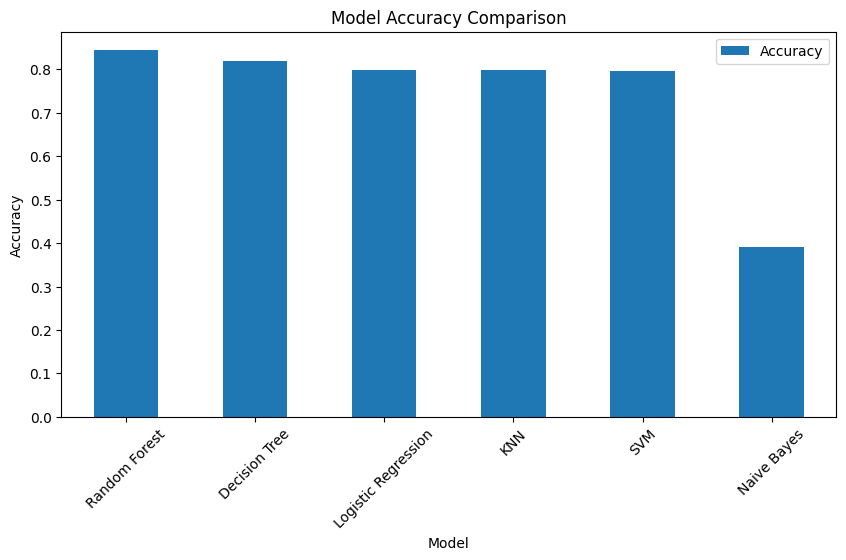

In [65]:
import matplotlib.pyplot as plt

results_df.plot(
    x="Model",
    y="Accuracy",
    kind="bar",
    figsize=(10,5)
)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=45)

plt.show()

In [66]:
#  SPRINT 3: OPTIMIZATION & FINAL MODEL

In [67]:
# Goal: Improve model performance and reliability

In [68]:

  # Step 1: Feature Engineering

In [69]:
# Total guests

df['total_guests'] = (
    df['adults']
    +
    df['children']
    +
    df['babies']
)

# Total stay duration

df['total_nights'] = (
    df['stays_in_weekend_nights']
    +
    df['stays_in_week_nights']
)

# Guests per room

df['guest_per_room'] = (
    df['total_guests']
    /
    (df['required_car_parking_spaces'] + 1)
)

print(df.head())

          hotel  is_canceled  lead_time  arrival_date_year arrival_date_month  \
0  Resort Hotel            0        342               2015               July   
1  Resort Hotel            0        737               2015               July   
2  Resort Hotel            0          7               2015               July   
3  Resort Hotel            0         13               2015               July   
4  Resort Hotel            0         14               2015               July   

   arrival_date_week_number  arrival_date_day_of_month  \
0                        27                          1   
1                        27                          1   
2                        27                          1   
3                        27                          1   
4                        27                          1   

   stays_in_weekend_nights  stays_in_week_nights  adults  ...  \
0                        0                     0       2  ...   
1                        0        

In [70]:
# Step 2A: Correlation Based Feature Selection

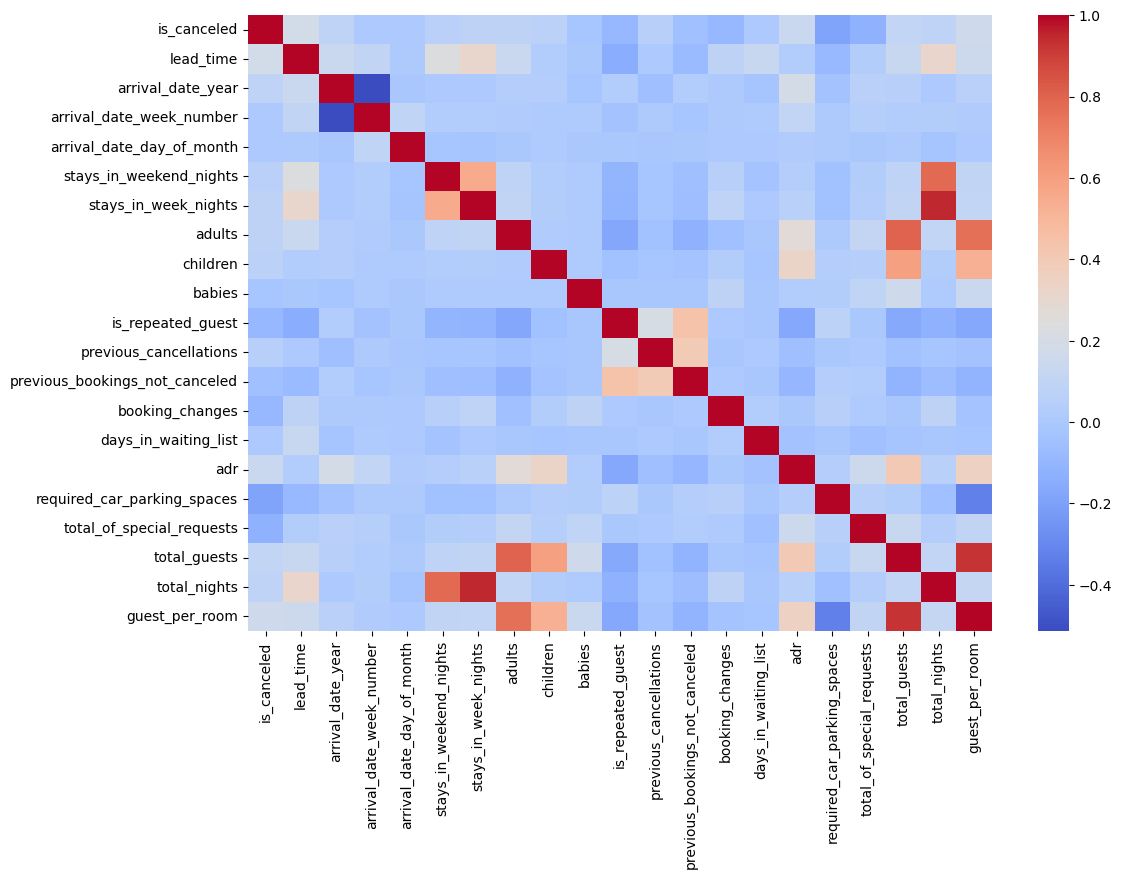

In [71]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(
        numeric_only=True
    ),
    cmap='coolwarm'
)

plt.show()

In [72]:
# Remove highly correlated columns:

In [73]:
corr_matrix = df.corr(
    numeric_only=True
).abs()

upper = corr_matrix.where(
    np.triu(
        np.ones(
            corr_matrix.shape
        ),
        k=1
    ).astype(bool)
)

drop_cols = [
    column
    for column in upper.columns
    if any(
        upper[column] > 0.90
    )
]

print(drop_cols)

['total_nights', 'guest_per_room']


In [74]:
# Step 2B: Feature Importance

#Use Random Forest:

In [75]:
import pandas as pd

rf = best_rf_model

feature_names = preprocessor.get_feature_names_out()

importance = pd.DataFrame({

    'Feature': feature_names,

    'Importance': rf.feature_importances_

})

importance = importance.sort_values(

    by='Importance',

    ascending=False

)

print(

importance.head(20)

)

                               Feature  Importance
0                       num__lead_time    0.129606
13                            num__adr    0.084357
15      num__total_of_special_requests    0.061959
2        num__arrival_date_week_number    0.060951
3       num__arrival_date_day_of_month    0.059712
149                   nom__country_PRT    0.049452
5            num__stays_in_week_nights    0.043949
16             ord__arrival_date_month    0.037309
195      nom__market_segment_Online TA    0.032774
14    num__required_car_parking_spaces    0.032104
1               num__arrival_date_year    0.027376
4         num__stays_in_weekend_nights    0.027075
11                num__booking_changes    0.019271
9          num__previous_cancellations    0.017666
194  nom__market_segment_Offline TA/TO    0.016564
6                          num__adults    0.016020
229       nom__customer_type_Transient    0.014458
225       nom__deposit_type_Non Refund    0.012706
212          nom__assigned_room

In [76]:
# Step 2C: Recursive Feature Elimination (RFE)

In [77]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

selector = RFE(

    estimator=

    LogisticRegression(

        max_iter=3000,

        random_state=42

    ),

    n_features_to_select=20

)

selector.fit(

    X_train_processed,

    y_train

)

selected_features = selector.support_

print(selected_features)

[False False False False False False False False False False False False
 False False  True False False False False False False False False False
 False  True False False False  True False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False  True False False  True False
 False False False  True False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False  True False False False False False False False False False
 False False False  True False False False False  True False False False
 False False False False False  True False False False False False  True
 False False False False False False False False Fa

In [78]:
# Step 3: Hyperparameter Tuning

#  already did GridSearch.

# Adding RandomizedSearch for optimization:

In [79]:
from sklearn.model_selection import RandomizedSearchCV

random_search = RandomizedSearchCV(

    estimator=best_rf_model,

    param_distributions={

        'n_estimators':[100,200],

        'max_depth':[10,None],

        'min_samples_split':[2,5]

    },

    n_iter=4,

    cv=3,

    scoring='accuracy',

    random_state=42,

    n_jobs=-1

)

random_search.fit(

    X_train_processed,

    y_train

)

print(random_search.best_params_)

{'n_estimators': 200, 'min_samples_split': 5, 'max_depth': None}


In [80]:
# Step 4: Build Final Model

In [81]:
final_model = random_search.best_estimator_

final_model.fit(

    X_train_processed,

    y_train

)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [82]:
# Step 5: Final Evaluation

In [83]:
from sklearn.metrics import classification_report

y_pred = final_model.predict(
    X_test_processed
)

print(

classification_report(

    y_test,

    y_pred

)

)

              precision    recall  f1-score   support

           0       0.86      0.94      0.90     12723
           1       0.77      0.60      0.67      4696

    accuracy                           0.84     17419
   macro avg       0.82      0.77      0.79     17419
weighted avg       0.84      0.84      0.84     17419



In [84]:
# Confusion Matrix:

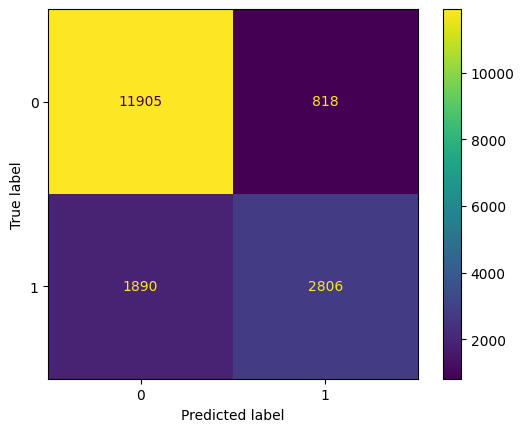

In [85]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(

    y_test,

    y_pred

)

In [86]:
# Step 6: Model Serialization (Required)
# Save model:

In [99]:
from sklearn.ensemble import RandomForestClassifier

rf_small = RandomForestClassifier(
    n_estimators=180,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)

rf_small.fit(
    X_train_processed,
    y_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",180
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [100]:
from sklearn.metrics import accuracy_score

old_pred = final_model.predict(X_test_processed)

new_pred = rf_small.predict(X_test_processed)

print(
    "Old Accuracy:",
    accuracy_score(y_test, old_pred)
)

print(
    "New Accuracy:",
    accuracy_score(y_test, new_pred)
)

Old Accuracy: 0.8445375739135427
New Accuracy: 0.8350077501578735


In [109]:
import pickle

with open("hotel_booking_model.pkl", "wb") as file:
    
    pickle.dump(
        final_model,
        file
    )
 
print("Model saved successfully")

Model saved successfully


In [88]:
# Load model:

In [110]:
import pickle

with open("hotel_booking_model.pkl", "rb") as file:

    loaded_model = pickle.load(file)

print("Model Loaded Successfully")

Model Loaded Successfully


In [111]:
y_pred = loaded_model.predict(
    X_test_processed
)

print(y_pred[:5])

[1 1 0 1 0]


In [112]:
import pickle
import os

# Save model
with open("hotel_booking_model.pkl", "wb") as file:
    pickle.dump(final_model, file)

# Check file size
size_bytes = os.path.getsize("hotel_booking_model.pkl")
size_kb = size_bytes / 1024
size_mb = size_bytes / (1024 * 1024)

print(f"Size: {size_kb:.2f} KB")
print(f"Size: {size_mb:.2f} MB")

Size: 326318.04 KB
Size: 318.67 MB


In [113]:
import joblib
import os

joblib.dump(
    rf_small,
    "hotel_booking_model.pkl",
    compress=("xz", 9)
)

size_mb = os.path.getsize(
    "hotel_booking_model.pkl"
) / (1024 * 1024)

print(
    f"Compressed Size: {size_mb:.2f} MB"
)

Compressed Size: 8.82 MB


In [114]:
import os

file_size = os.path.getsize(
    "hotel_booking_model.pkl"
) / (1024 * 1024)

if file_size < 100:
    print("Safe for GitHub")
else:
    print("Too large for GitHub")

Safe for GitHub
